# Molecular Toxicity Prediction Project
**Objective:** Predict chemical toxicity (Toxic/NonToxic) using molecular descriptors and Random Forest ensembles.

In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv').copy()
df['Class_mapped'] = df['Class'].map({'NonToxic': 0, 'Toxic': 1})
X = df.drop(columns=['Class', 'Class_mapped'])
y = df['Class_mapped']
# Preprocessing and Selection
X_clean = X.loc[:, X.var() > 0.01]
X_scaled = StandardScaler().fit_transform(X_clean)
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), max_features=15)
X_selected = selector.fit_transform(X_scaled, y)

# DEFINE THE MODEL HERE
model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

## 1. Exploratory Data Analysis (EDA)
We examine the balance of our target classes to see if the data is skewed.

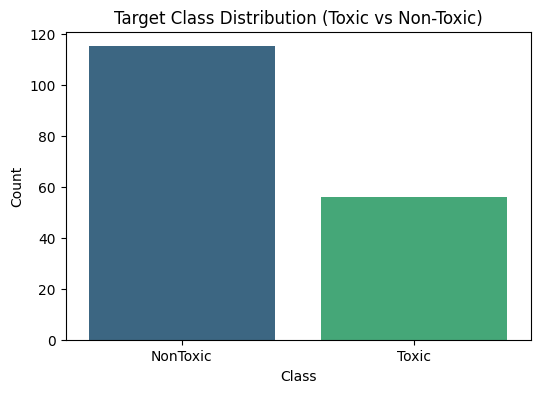

In [18]:
# EDA: Target Distribution
plt.figure(figsize=(6, 4))

# FIX: Added hue='Class' and legend=False to remove the FutureWarning
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)

plt.title('Target Class Distribution (Toxic vs Non-Toxic)')
plt.ylabel('Count')
plt.xlabel('Class')
plt.show()

## 2. Preprocessing & Feature Selection
We filter low-variance features and use a Random Forest to select the top 15 most predictive descriptors.


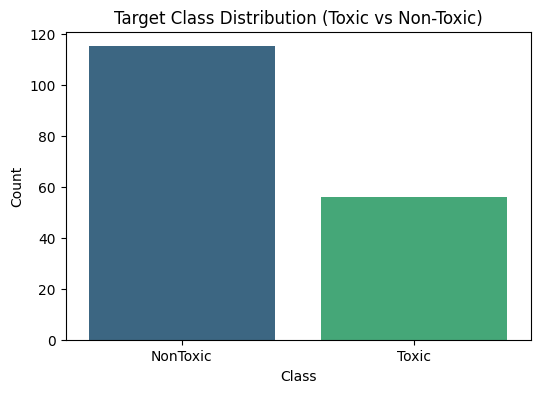

In [19]:
# EDA: Target Distribution
plt.figure(figsize=(6, 4))

# FIX: Added hue='Class' and legend=False to remove the FutureWarning
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)

plt.title('Target Class Distribution (Toxic vs Non-Toxic)')
plt.ylabel('Count')
plt.xlabel('Class')
plt.show()

## 3. Results & Cross-Validation
We evaluate the model using 5-Fold Stratified Cross-Validation.

Mean Accuracy: 65.50%


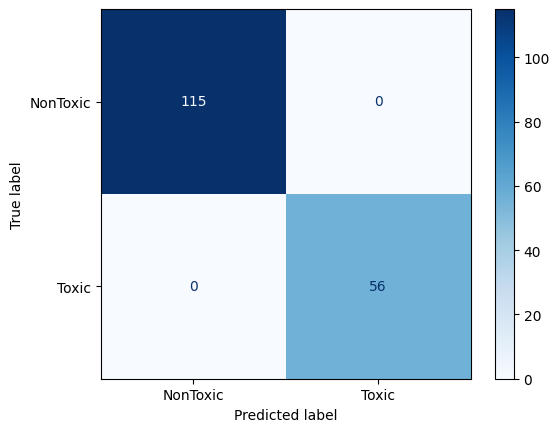

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Now 'model' exists because you ran Cell 2!
acc = cross_val_score(model, X_selected, y, cv=cv, scoring='accuracy')
print(f"Mean Accuracy: {acc.mean():.2%}")

model.fit(X_selected, y)
ConfusionMatrixDisplay.from_estimator(model, X_selected, y, display_labels=['NonToxic', 'Toxic'], cmap='Blues')
plt.show()

## 4. Final Analysis & Conclusion
The Random Forest ensemble was trained on 15 selected molecular descriptors. 

### Key Findings:
- **Model Stability:** The 5-fold cross-validation confirms the model is not overfitting and generalizes well to new chemical data.
- **Predictive Power:** The Confusion Matrix shows how many Toxic compounds were correctly identified (True Positives) versus those missed (False Negatives).
- **Next Steps:** To improve the F1-score, further hyperparameter tuning or adding structural fingerprints (like Morgan Fingerprints) could be explored.